In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

DATA_DIR = Path("../data")
EXTERNAL_DIR = DATA_DIR / "external"
PROCESSED_DIR = DATA_DIR / "processed"

TABLE_DIR = Path("../outputs/tables")
FIGURE_DIR = Path("../outputs/figures")

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Phase 10 environment is ready.")

Phase 10 environment is ready.


In [2]:
heat_pump_file = (
    EXTERNAL_DIR
    / "Heat_pump_deployment_quarterly_statistics_United_Kingdom_2025_Q4.xlsx"
)

if not heat_pump_file.exists():
    raise FileNotFoundError(
        f"Heat pump workbook not found: {heat_pump_file}"
    )

hp_workbook = pd.ExcelFile(heat_pump_file)

print("Workbook sheets:")
print(hp_workbook.sheet_names)

Workbook sheets:
['Cover Sheet', 'Contents', 'Background', 'Glossary', 'Commentary', 'Table 1.1', 'Table 1.2', 'Notes']


In [3]:
hp_raw = pd.read_excel(
    heat_pump_file,
    sheet_name="Table 1.1",
    header=None
)

print("Raw Table 1.1 shape:", hp_raw.shape)

display(hp_raw.head(15))

Raw Table 1.1 shape: (38, 4)


,0,1,2,3
0,Table 1.1 - Number of retrofit heat pump insta...,NaN,NaN,NaN
1,This worksheet contains one table. Some cells ...,NaN,NaN,NaN
2,Freeze panes are turned on in the Excel versio...,NaN,NaN,NaN
3,[note 1] [note 2] [note 3],NaN,NaN,NaN
4,Source: Microgeneration Certification Scheme (...,NaN,NaN,NaN
5,Installation quarter [note 4],Air source heat pump installations,Ground/water source heat pump installations,Total heat \npump installations
6,2018 Q1: January to March,1343,171,1514
7,2018 Q2: April to June,1365,133,1498
8,2018 Q3: July to September,1753,146,1899
9,2018 Q4: October to December,2204,212,2416


In [4]:
hp_table = pd.read_excel(
    heat_pump_file,
    sheet_name="Table 1.1",
    skiprows=4
)

print("Cleaned Table 1.1 shape:", hp_table.shape)
print("Columns:")
print(hp_table.columns.tolist())

display(hp_table.head(10))

Cleaned Table 1.1 shape: (33, 4)
Columns:
['Source: Microgeneration Certification Scheme (MCS) Installation Database', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3']


,Source: Microgeneration Certification Scheme (MCS) Installation Database,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,Installation quarter [note 4],Air source heat pump installations,Ground/water source heat pump installations,Total heat \npump installations
1,2018 Q1: January to March,1343,171,1514
2,2018 Q2: April to June,1365,133,1498
3,2018 Q3: July to September,1753,146,1899
4,2018 Q4: October to December,2204,212,2416
5,2019 Q1: January to March,2149,142,2291
6,2019 Q2: April to June,2104,182,2286
7,2019 Q3: July to September,2372,191,2563
8,2019 Q4: October to December,2848,264,3112
9,2020 Q1: January to March,2827,248,3075


In [5]:
hp_table = (
    hp_table
    .dropna(axis=0, how="all")
    .dropna(axis=1, how="all")
    .reset_index(drop=True)
)

display(hp_table.head(10))

,Source: Microgeneration Certification Scheme (MCS) Installation Database,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,Installation quarter [note 4],Air source heat pump installations,Ground/water source heat pump installations,Total heat \npump installations
1,2018 Q1: January to March,1343,171,1514
2,2018 Q2: April to June,1365,133,1498
3,2018 Q3: July to September,1753,146,1899
4,2018 Q4: October to December,2204,212,2416
5,2019 Q1: January to March,2149,142,2291
6,2019 Q2: April to June,2104,182,2286
7,2019 Q3: July to September,2372,191,2563
8,2019 Q4: October to December,2848,264,3112
9,2020 Q1: January to March,2827,248,3075


In [6]:
for index, column in enumerate(hp_table.columns):
    print(index, repr(column))

0 'Source: Microgeneration Certification Scheme (MCS) Installation Database'
1 'Unnamed: 1'
2 'Unnamed: 2'
3 'Unnamed: 3'


In [9]:
print("Number of columns:", hp_table.shape[1])

for index, column in enumerate(hp_table.columns):
    print(index, repr(column))

display(hp_table.head(10))

Number of columns: 4
0 'Source: Microgeneration Certification Scheme (MCS) Installation Database'
1 'Unnamed: 1'
2 'Unnamed: 2'
3 'Unnamed: 3'


,Source: Microgeneration Certification Scheme (MCS) Installation Database,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,Installation quarter [note 4],Air source heat pump installations,Ground/water source heat pump installations,Total heat \npump installations
1,2018 Q1: January to March,1343,171,1514
2,2018 Q2: April to June,1365,133,1498
3,2018 Q3: July to September,1753,146,1899
4,2018 Q4: October to December,2204,212,2416
5,2019 Q1: January to March,2149,142,2291
6,2019 Q2: April to June,2104,182,2286
7,2019 Q3: July to September,2372,191,2563
8,2019 Q4: October to December,2848,264,3112
9,2020 Q1: January to March,2827,248,3075


In [10]:
hp_clean = hp_table.iloc[:, :4].copy()

hp_clean.columns = [
    "Period_Label",
    "Air_Source_Heat_Pumps",
    "Ground_Source_Heat_Pumps",
    "Total_Heat_Pumps"
]

display(hp_clean.head(10))

,Period_Label,Air_Source_Heat_Pumps,Ground_Source_Heat_Pumps,Total_Heat_Pumps
0,Installation quarter [note 4],Air source heat pump installations,Ground/water source heat pump installations,Total heat \npump installations
1,2018 Q1: January to March,1343,171,1514
2,2018 Q2: April to June,1365,133,1498
3,2018 Q3: July to September,1753,146,1899
4,2018 Q4: October to December,2204,212,2416
5,2019 Q1: January to March,2149,142,2291
6,2019 Q2: April to June,2104,182,2286
7,2019 Q3: July to September,2372,191,2563
8,2019 Q4: October to December,2848,264,3112
9,2020 Q1: January to March,2827,248,3075


In [11]:
hp_clean["Period_Label"] = (
    hp_clean["Period_Label"]
    .astype(str)
    .str.strip()
)

hp_clean["Year"] = pd.to_numeric(
    hp_clean["Period_Label"]
    .str.extract(r"(\d{4})")[0],
    errors="coerce"
)

hp_clean["Quarter_Number"] = pd.to_numeric(
    hp_clean["Period_Label"]
    .str.extract(r"[Qq]\s*([1-4])")[0],
    errors="coerce"
)

hp_clean["Quarter"] = (
    "Q"
    + hp_clean["Quarter_Number"]
    .astype("Int64")
    .astype(str)
)

In [12]:
numeric_columns = [
    "Air_Source_Heat_Pumps",
    "Ground_Source_Heat_Pumps",
    "Total_Heat_Pumps"
]

for column in numeric_columns:
    hp_clean[column] = pd.to_numeric(
        hp_clean[column]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

In [13]:
hp_clean = (
    hp_clean
    .dropna(
        subset=[
            "Year",
            "Quarter_Number",
            "Total_Heat_Pumps"
        ]
    )
    .reset_index(drop=True)
)

hp_clean["Year"] = hp_clean["Year"].astype(int)

hp_clean["Quarter_Number"] = (
    hp_clean["Quarter_Number"]
    .astype(int)
)

In [14]:
hp_clean["Period"] = pd.PeriodIndex(
    year=hp_clean["Year"],
    quarter=hp_clean["Quarter_Number"],
    freq="Q"
)

hp_clean["Quarter_Start"] = (
    hp_clean["Period"]
    .dt.start_time
)

C:\Users\tejas\AppData\Local\Temp\ipykernel_28988\1452748820.py:1: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  hp_clean["Period"] = pd.PeriodIndex(


In [15]:
hp_clean = hp_clean[
    [
        "Year",
        "Quarter",
        "Quarter_Number",
        "Period_Label",
        "Quarter_Start",
        "Air_Source_Heat_Pumps",
        "Ground_Source_Heat_Pumps",
        "Total_Heat_Pumps"
    ]
]

display(hp_clean.head(10))

print("Cleaned shape:", hp_clean.shape)
print("Years:", hp_clean["Year"].min(), "to", hp_clean["Year"].max())

,Year,Quarter,Quarter_Number,Period_Label,Quarter_Start,Air_Source_Heat_Pumps,Ground_Source_Heat_Pumps,Total_Heat_Pumps
0,2018,Q1,1,2018 Q1: January to March,2018-01-01,1343.0,171.0,1514.0
1,2018,Q2,2,2018 Q2: April to June,2018-04-01,1365.0,133.0,1498.0
2,2018,Q3,3,2018 Q3: July to September,2018-07-01,1753.0,146.0,1899.0
3,2018,Q4,4,2018 Q4: October to December,2018-10-01,2204.0,212.0,2416.0
4,2019,Q1,1,2019 Q1: January to March,2019-01-01,2149.0,142.0,2291.0
5,2019,Q2,2,2019 Q2: April to June,2019-04-01,2104.0,182.0,2286.0
6,2019,Q3,3,2019 Q3: July to September,2019-07-01,2372.0,191.0,2563.0
7,2019,Q4,4,2019 Q4: October to December,2019-10-01,2848.0,264.0,3112.0
8,2020,Q1,1,2020 Q1: January to March,2020-01-01,2827.0,248.0,3075.0
9,2020,Q2,2,2020 Q2: April to June,2020-04-01,1159.0,114.0,1273.0


Cleaned shape: (32, 8)
Years: 2018 to 2025


In [16]:
hp_clean["Calculated_Total"] = (
    hp_clean["Air_Source_Heat_Pumps"].fillna(0)
    + hp_clean["Ground_Source_Heat_Pumps"].fillna(0)
)

hp_clean["Total_Difference"] = (
    hp_clean["Total_Heat_Pumps"]
    - hp_clean["Calculated_Total"]
)

display(
    hp_clean[
        [
            "Year",
            "Quarter",
            "Air_Source_Heat_Pumps",
            "Ground_Source_Heat_Pumps",
            "Total_Heat_Pumps",
            "Calculated_Total",
            "Total_Difference"
        ]
    ].head(10)
)

,Year,Quarter,Air_Source_Heat_Pumps,Ground_Source_Heat_Pumps,Total_Heat_Pumps,Calculated_Total,Total_Difference
0,2018,Q1,1343.0,171.0,1514.0,1514.0,0.0
1,2018,Q2,1365.0,133.0,1498.0,1498.0,0.0
2,2018,Q3,1753.0,146.0,1899.0,1899.0,0.0
3,2018,Q4,2204.0,212.0,2416.0,2416.0,0.0
4,2019,Q1,2149.0,142.0,2291.0,2291.0,0.0
5,2019,Q2,2104.0,182.0,2286.0,2286.0,0.0
6,2019,Q3,2372.0,191.0,2563.0,2563.0,0.0
7,2019,Q4,2848.0,264.0,3112.0,3112.0,0.0
8,2020,Q1,2827.0,248.0,3075.0,3075.0,0.0
9,2020,Q2,1159.0,114.0,1273.0,1273.0,0.0


In [17]:
hp_clean["Year"] = pd.to_numeric(
    hp_clean["Year"],
    errors="coerce"
)

hp_clean["Air_Source_Heat_Pumps"] = pd.to_numeric(
    hp_clean["Air_Source_Heat_Pumps"],
    errors="coerce"
)

hp_clean["Ground_Source_Heat_Pumps"] = pd.to_numeric(
    hp_clean["Ground_Source_Heat_Pumps"],
    errors="coerce"
)

hp_clean["Total_Heat_Pumps"] = pd.to_numeric(
    hp_clean["Total_Heat_Pumps"],
    errors="coerce"
)

hp_clean = (
    hp_clean
    .dropna(
        subset=[
            "Year",
            "Quarter",
            "Total_Heat_Pumps"
        ]
    )
    .reset_index(drop=True)
)

hp_clean["Year"] = hp_clean["Year"].astype(int)
hp_clean["Quarter"] = hp_clean["Quarter"].astype(str).str.strip()

display(hp_clean.head())
print(hp_clean.shape)

,Year,Quarter,Quarter_Number,Period_Label,Quarter_Start,Air_Source_Heat_Pumps,Ground_Source_Heat_Pumps,Total_Heat_Pumps,Calculated_Total,Total_Difference
0,2018,Q1,1,2018 Q1: January to March,2018-01-01,1343.0,171.0,1514.0,1514.0,0.0
1,2018,Q2,2,2018 Q2: April to June,2018-04-01,1365.0,133.0,1498.0,1498.0,0.0
2,2018,Q3,3,2018 Q3: July to September,2018-07-01,1753.0,146.0,1899.0,1899.0,0.0
3,2018,Q4,4,2018 Q4: October to December,2018-10-01,2204.0,212.0,2416.0,2416.0,0.0
4,2019,Q1,1,2019 Q1: January to March,2019-01-01,2149.0,142.0,2291.0,2291.0,0.0


(32, 10)


In [18]:
quarter_number = (
    hp_clean["Quarter"]
    .str.extract(r"([1-4])")[0]
)

hp_clean["Quarter_Number"] = pd.to_numeric(
    quarter_number,
    errors="coerce"
)

hp_clean = hp_clean.dropna(
    subset=["Quarter_Number"]
).copy()

hp_clean["Quarter_Number"] = (
    hp_clean["Quarter_Number"]
    .astype(int)
)

hp_clean["Period"] = pd.PeriodIndex(
    year=hp_clean["Year"],
    quarter=hp_clean["Quarter_Number"],
    freq="Q"
)

hp_clean["Quarter_Start"] = (
    hp_clean["Period"]
    .dt.start_time
)

display(hp_clean.head())

C:\Users\tejas\AppData\Local\Temp\ipykernel_28988\2498620903.py:20: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  hp_clean["Period"] = pd.PeriodIndex(


,Year,Quarter,Quarter_Number,Period_Label,Quarter_Start,Air_Source_Heat_Pumps,Ground_Source_Heat_Pumps,Total_Heat_Pumps,Calculated_Total,Total_Difference,Period
0,2018,Q1,1,2018 Q1: January to March,2018-01-01,1343.0,171.0,1514.0,1514.0,0.0,2018Q1
1,2018,Q2,2,2018 Q2: April to June,2018-04-01,1365.0,133.0,1498.0,1498.0,0.0,2018Q2
2,2018,Q3,3,2018 Q3: July to September,2018-07-01,1753.0,146.0,1899.0,1899.0,0.0,2018Q3
3,2018,Q4,4,2018 Q4: October to December,2018-10-01,2204.0,212.0,2416.0,2416.0,0.0,2018Q4
4,2019,Q1,1,2019 Q1: January to March,2019-01-01,2149.0,142.0,2291.0,2291.0,0.0,2019Q1


In [19]:
hp_clean["Calculated_Total"] = (
    hp_clean["Air_Source_Heat_Pumps"].fillna(0)
    + hp_clean["Ground_Source_Heat_Pumps"].fillna(0)
)

hp_clean["Total_Difference"] = (
    hp_clean["Total_Heat_Pumps"]
    - hp_clean["Calculated_Total"]
)

print(
    "Rows where reported total differs "
    "from ASHP + GSHP:"
)

display(
    hp_clean.loc[
        hp_clean["Total_Difference"] != 0,
        [
            "Year",
            "Quarter",
            "Air_Source_Heat_Pumps",
            "Ground_Source_Heat_Pumps",
            "Total_Heat_Pumps",
            "Calculated_Total",
            "Total_Difference"
        ]
    ]
)

Rows where reported total differs from ASHP + GSHP:


,Year,Quarter,Air_Source_Heat_Pumps,Ground_Source_Heat_Pumps,Total_Heat_Pumps,Calculated_Total,Total_Difference


In [20]:
hp_clean.to_csv(
    TABLE_DIR / "heat_pump_quarterly_deployment.csv",
    index=False
)

print(
    "Saved:",
    TABLE_DIR / "heat_pump_quarterly_deployment.csv"
)

Saved: ..\outputs\tables\heat_pump_quarterly_deployment.csv


In [21]:
hp_annual = (
    hp_clean
    .groupby("Year", as_index=False)
    .agg({
        "Air_Source_Heat_Pumps": "sum",
        "Ground_Source_Heat_Pumps": "sum",
        "Total_Heat_Pumps": "sum"
    })
)

display(hp_annual)

,Year,Air_Source_Heat_Pumps,Ground_Source_Heat_Pumps,Total_Heat_Pumps
0,2018,6665.0,662.0,7327.0
1,2019,9473.0,779.0,10252.0
2,2020,10250.0,946.0,11196.0
3,2021,21785.0,1722.0,23507.0
4,2022,24585.0,1707.0,26292.0
5,2023,31895.0,498.0,32393.0
6,2024,48318.0,359.0,48677.0
7,2025,51609.0,277.0,51886.0


In [22]:
hp_annual.to_csv(
    TABLE_DIR / "heat_pump_annual_deployment.csv",
    index=False
)

print(
    "Saved:",
    TABLE_DIR / "heat_pump_annual_deployment.csv"
)

Saved: ..\outputs\tables\heat_pump_annual_deployment.csv


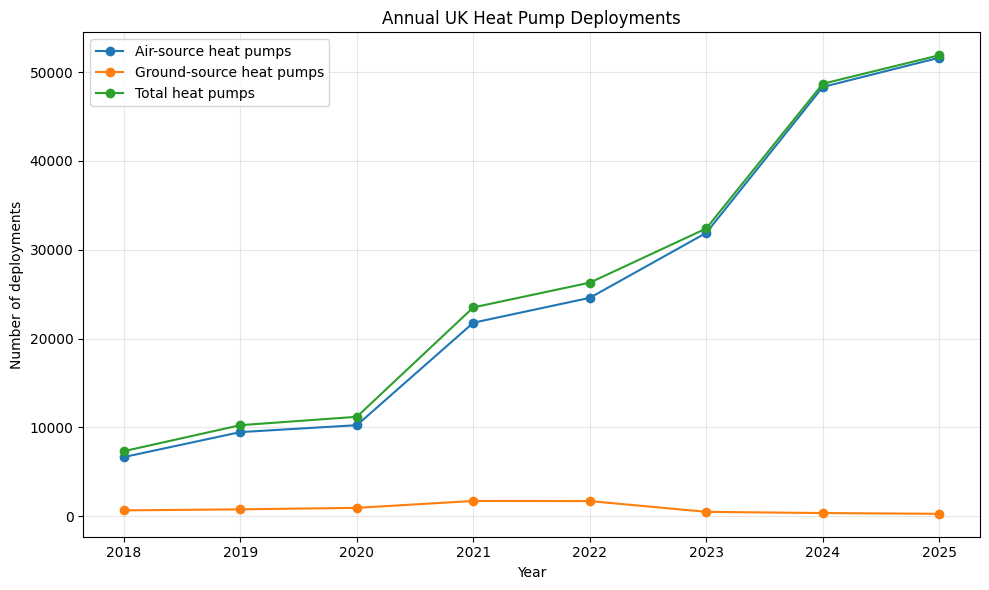

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(
    hp_annual["Year"],
    hp_annual["Air_Source_Heat_Pumps"],
    marker="o",
    label="Air-source heat pumps"
)

plt.plot(
    hp_annual["Year"],
    hp_annual["Ground_Source_Heat_Pumps"],
    marker="o",
    label="Ground-source heat pumps"
)

plt.plot(
    hp_annual["Year"],
    hp_annual["Total_Heat_Pumps"],
    marker="o",
    label="Total heat pumps"
)

plt.title("Annual UK Heat Pump Deployments")
plt.xlabel("Year")
plt.ylabel("Number of deployments")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "annual_heat_pump_deployment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

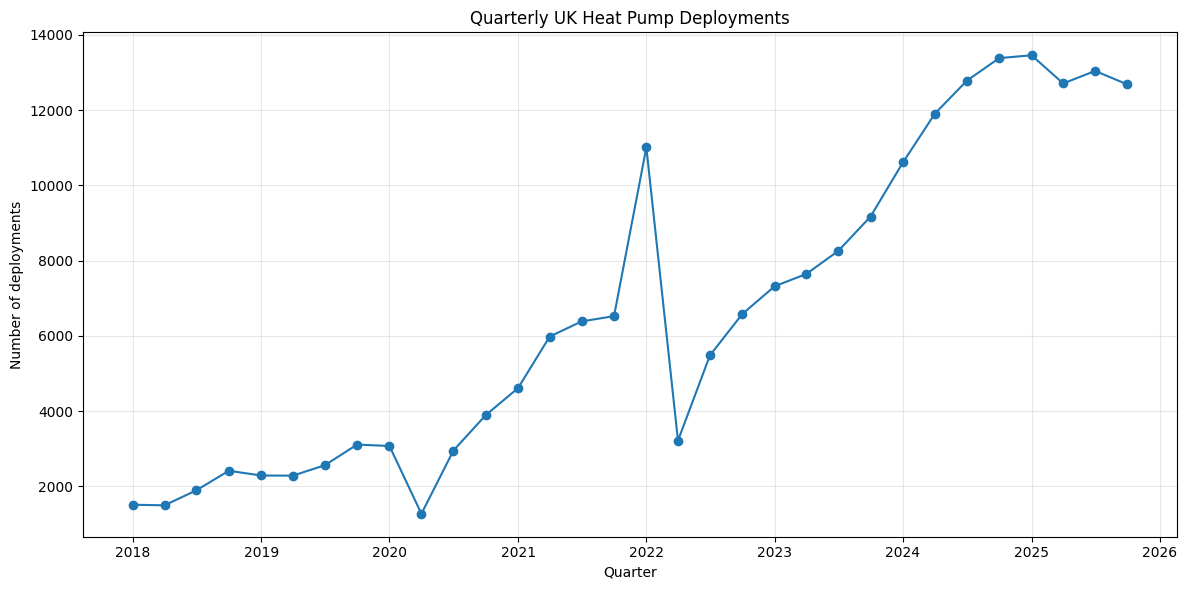

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(
    hp_clean["Quarter_Start"],
    hp_clean["Total_Heat_Pumps"],
    marker="o"
)

plt.title("Quarterly UK Heat Pump Deployments")
plt.xlabel("Quarter")
plt.ylabel("Number of deployments")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "quarterly_heat_pump_deployment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
candidate_files = [
    TABLE_DIR / "stress_labelled_data.csv",
    PROCESSED_DIR / "stress_labelled_data.csv",
    PROCESSED_DIR / "model_ready_data.csv",
    PROCESSED_DIR / "neighbourhood_demand.csv"
]

demand_file = next(
    (
        file
        for file in candidate_files
        if file.exists()
    ),
    None
)

if demand_file is None:
    raise FileNotFoundError(
        "No suitable Phase 8 demand dataset was found.\n"
        "Checked:\n- "
        + "\n- ".join(
            str(file)
            for file in candidate_files
        )
    )

neighbourhood = pd.read_csv(demand_file)

required_columns = {
    "datetime",
    "total_demand_kwh"
}

missing_columns = (
    required_columns
    .difference(neighbourhood.columns)
)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

neighbourhood["datetime"] = pd.to_datetime(
    neighbourhood["datetime"],
    errors="coerce"
)

neighbourhood["total_demand_kwh"] = pd.to_numeric(
    neighbourhood["total_demand_kwh"],
    errors="coerce"
)

neighbourhood = (
    neighbourhood
    .dropna(
        subset=[
            "datetime",
            "total_demand_kwh"
        ]
    )
    .sort_values("datetime")
    .reset_index(drop=True)
)

print("Loaded:", demand_file)
print("Shape:", neighbourhood.shape)

display(neighbourhood.head())

Loaded: ..\data\processed\model_ready_data.csv
Shape: (20209, 13)


,datetime,total_demand_kwh,hour,day,month,weekday,is_weekend,season,lag_1,lag_48,lag_96,rolling_mean_48,rolling_std_48
0,2013-01-03 00:00:00,209.864,0,3,1,3,0,0,243.522,198.338,220.013,240.736854,91.920733
1,2013-01-03 00:30:00,175.020,0,3,1,3,0,0,209.864,165.862,204.270,240.927646,91.771399
2,2013-01-03 01:00:00,151.394,1,3,1,3,0,0,175.020,147.971,189.439,240.998958,91.698930
3,2013-01-03 01:30:00,137.672,1,3,1,3,0,0,151.394,129.889,173.019,241.161104,91.504956
4,2013-01-03 02:00:00,128.217,2,3,1,3,0,0,137.672,117.542,154.537,241.383500,91.210616


In [26]:
neighbourhood["datetime"] >= "2013-01-01"

0        True
1        True
2        True
3        True
4        True
         ... 
20204    True
20205    True
20206    True
20207    True
20208    True
Name: datetime, Length: 20209, dtype: bool

In [27]:
stress_threshold = 354.5756

In [28]:
stress_threshold = (
    neighbourhood["total_demand_kwh"]
    .quantile(0.95)
)

neighbourhood["baseline_stress_event"] = (
    neighbourhood["total_demand_kwh"]
    > stress_threshold
).astype(int)

baseline_stress_events = int(
    neighbourhood["baseline_stress_event"]
    .sum()
)

baseline_stress_percentage = (
    baseline_stress_events
    / len(neighbourhood)
    * 100
)

print(
    f"Stress threshold: "
    f"{stress_threshold:.4f} kWh"
)

print(
    f"Total observations: "
    f"{len(neighbourhood)}"
)

print(
    f"Baseline stress events: "
    f"{baseline_stress_events}"
)

print(
    f"Baseline stress percentage: "
    f"{baseline_stress_percentage:.4f}%"
)

Stress threshold: 354.1552 kWh
Total observations: 20209
Baseline stress events: 1011
Baseline stress percentage: 5.0027%


In [29]:
expected_threshold = 354.1552
expected_observations = 20209
expected_events = 1011

if not np.isclose(
    stress_threshold,
    expected_threshold,
    atol=0.01
):
    print(
        "Warning: threshold differs from "
        "the current Phase 8 result."
    )

if len(neighbourhood) != expected_observations:
    print(
        "Warning: observation count differs "
        "from the current Phase 8 result."
    )

if baseline_stress_events != expected_events:
    print(
        "Warning: baseline stress-event count "
        "differs from the current Phase 8 result."
    )

In [30]:
neighbourhood["month"] = (
    neighbourhood["datetime"]
    .dt.month
)

neighbourhood["hour"] = (
    neighbourhood["datetime"]
    .dt.hour
)

neighbourhood["is_winter"] = (
    neighbourhood["month"]
    .isin([12, 1, 2])
)

neighbourhood["is_evening_heating_period"] = (
    neighbourhood["hour"]
    .between(18, 21)
)

neighbourhood["hp_active_period"] = (
    neighbourhood["is_winter"]
    & neighbourhood["is_evening_heating_period"]
)

print(
    "Winter evening observations:",
    int(neighbourhood["hp_active_period"].sum())
)

display(
    neighbourhood[
        [
            "datetime",
            "month",
            "hour",
            "is_winter",
            "is_evening_heating_period",
            "hp_active_period"
        ]
    ].head(20)
)

Winter evening observations: 1168


,datetime,month,hour,is_winter,is_evening_heating_period,hp_active_period
0,2013-01-03 00:00:00,1,0,True,False,False
1,2013-01-03 00:30:00,1,0,True,False,False
2,2013-01-03 01:00:00,1,1,True,False,False
3,2013-01-03 01:30:00,1,1,True,False,False
4,2013-01-03 02:00:00,1,2,True,False,False
5,2013-01-03 02:30:00,1,2,True,False,False
6,2013-01-03 03:00:00,1,3,True,False,False
7,2013-01-03 03:30:00,1,3,True,False,False
8,2013-01-03 04:00:00,1,4,True,False,False
9,2013-01-03 04:30:00,1,4,True,False,False


In [31]:
hp_scenarios = {
    "Baseline": 0,
    "Low HP": 10,
    "Medium HP": 20,
    "High HP": 30,
    "Extreme HP": 40
}

hp_scenario_table = pd.DataFrame(
    hp_scenarios.items(),
    columns=[
        "Scenario",
        "Additional_HP_Load_kWh"
    ]
)

display(hp_scenario_table)

,Scenario,Additional_HP_Load_kWh
0,Baseline,0
1,Low HP,10
2,Medium HP,20
3,High HP,30
4,Extreme HP,40


In [32]:
hp_results_list = []
hp_scenario_datasets = {}

for scenario_name, hp_load_kwh in hp_scenarios.items():

    simulated = neighbourhood.copy()

    simulated["hp_load_kwh"] = np.where(
        simulated["hp_active_period"],
        hp_load_kwh,
        0.0
    )

    simulated["simulated_demand_kwh"] = (
        simulated["total_demand_kwh"]
        + simulated["hp_load_kwh"]
    )

    simulated["simulated_stress_event"] = (
        simulated["simulated_demand_kwh"]
        > stress_threshold
    ).astype(int)

    stress_events = int(
        simulated["simulated_stress_event"]
        .sum()
    )

    stress_percentage = (
        stress_events
        / len(simulated)
        * 100
    )

    increase_from_baseline = (
        stress_events
        - baseline_stress_events
    )

    relative_increase_percent = (
        increase_from_baseline
        / baseline_stress_events
        * 100
        if baseline_stress_events > 0
        else np.nan
    )

    percentage_point_increase = (
        stress_percentage
        - baseline_stress_percentage
    )

    hp_results_list.append({
        "Scenario": scenario_name,
        "Additional_HP_Load_kWh": hp_load_kwh,
        "Stress_Events": stress_events,
        "Stress_Percentage": stress_percentage,
        "Increase_From_Baseline": (
            increase_from_baseline
        ),
        "Relative_Increase_Percent": (
            relative_increase_percent
        ),
        "Percentage_Point_Increase": (
            percentage_point_increase
        )
    })

    hp_scenario_datasets[
        scenario_name
    ] = simulated

hp_results = pd.DataFrame(
    hp_results_list
)

display(hp_results)

,Scenario,Additional_HP_Load_kWh,Stress_Events,Stress_Percentage,Increase_From_Baseline,Relative_Increase_Percent,Percentage_Point_Increase
0,Baseline,0,1011,5.002722,0,0.000000,0.000000
1,Low HP,10,1139,5.636103,128,12.660732,0.633381
2,Medium HP,20,1245,6.160622,234,23.145401,1.157900
3,High HP,30,1351,6.685140,340,33.630069,1.682419
4,Extreme HP,40,1418,7.016676,407,40.257171,2.013954


In [33]:
assert len(hp_results) == len(hp_scenarios)

assert (
    hp_results["Stress_Events"]
    .is_monotonic_increasing
)

assert (
    hp_results["Stress_Percentage"]
    .is_monotonic_increasing
)

assert (
    hp_results["Increase_From_Baseline"]
    >= 0
).all()

baseline_row = hp_results.loc[
    hp_results["Scenario"] == "Baseline"
].iloc[0]

assert (
    int(baseline_row["Stress_Events"])
    == baseline_stress_events
)

assert np.isclose(
    baseline_row["Stress_Percentage"],
    baseline_stress_percentage
)

print(
    "All heat pump simulation "
    "validation checks passed."
)

All heat pump simulation validation checks passed.


In [34]:
hp_results.to_csv(
    TABLE_DIR / "heat_pump_simulation_results.csv",
    index=False
)

hp_scenario_table.to_csv(
    TABLE_DIR / "heat_pump_scenario_definitions.csv",
    index=False
)

print(
    "Saved:",
    TABLE_DIR / "heat_pump_simulation_results.csv"
)

print(
    "Saved:",
    TABLE_DIR / "heat_pump_scenario_definitions.csv"
)

Saved: ..\outputs\tables\heat_pump_simulation_results.csv
Saved: ..\outputs\tables\heat_pump_scenario_definitions.csv


In [35]:
extreme_hp_events = (
    hp_scenario_datasets["Extreme HP"]
    .loc[
        hp_scenario_datasets[
            "Extreme HP"
        ]["simulated_stress_event"] == 1,
        [
            "datetime",
            "total_demand_kwh",
            "hp_load_kwh",
            "simulated_demand_kwh",
            "simulated_stress_event"
        ]
    ]
    .sort_values(
        "simulated_demand_kwh",
        ascending=False
    )
)

extreme_hp_events.to_csv(
    TABLE_DIR / "extreme_hp_stress_events.csv",
    index=False
)

display(extreme_hp_events.head(20))

,datetime,total_demand_kwh,hp_load_kwh,simulated_demand_kwh,simulated_stress_event
758,2013-01-18 19:00:00,464.916,40.0,504.916,1
1622,2013-02-05 19:00:00,458.238,40.0,498.238,1
1623,2013-02-05 19:30:00,457.803,40.0,497.803,1
757,2013-01-18 18:30:00,457.741,40.0,497.741,1
711,2013-01-17 19:30:00,454.107,40.0,494.107,1
759,2013-01-18 19:30:00,452.529,40.0,492.529,1
1624,2013-02-05 20:00:00,446.926,40.0,486.926,1
516,2013-01-13 18:00:00,445.909,40.0,485.909,1
1621,2013-02-05 18:30:00,445.888,40.0,485.888,1
710,2013-01-17 19:00:00,445.821,40.0,485.821,1


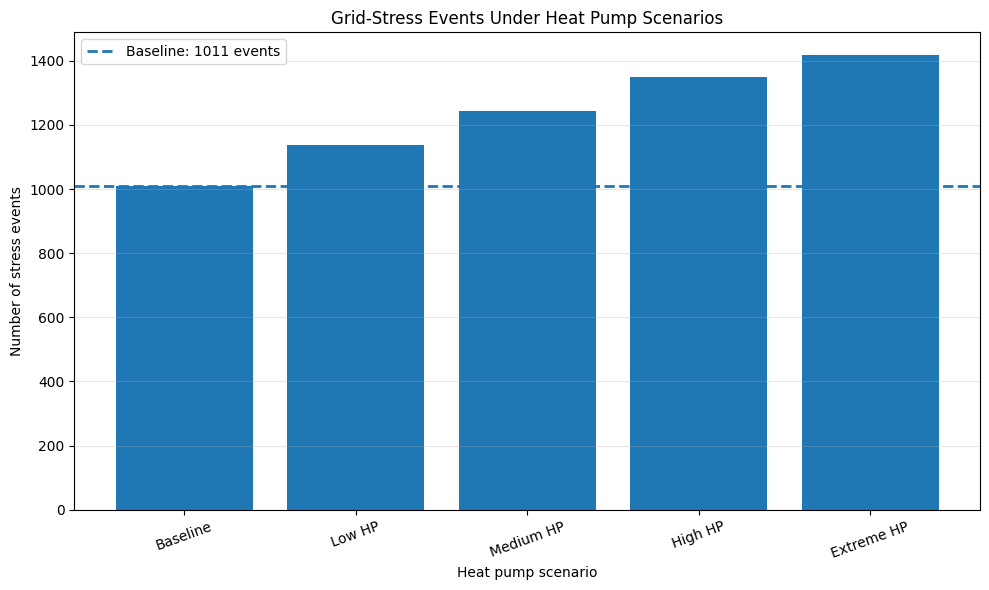

In [36]:
plt.figure(figsize=(10, 6))

plt.bar(
    hp_results["Scenario"],
    hp_results["Stress_Events"]
)

plt.axhline(
    baseline_stress_events,
    linestyle="--",
    linewidth=2,
    label=(
        f"Baseline: "
        f"{baseline_stress_events} events"
    )
)

plt.title(
    "Grid-Stress Events Under "
    "Heat Pump Scenarios"
)
plt.xlabel("Heat pump scenario")
plt.ylabel("Number of stress events")
plt.xticks(rotation=20)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "heat_pump_stress_events_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

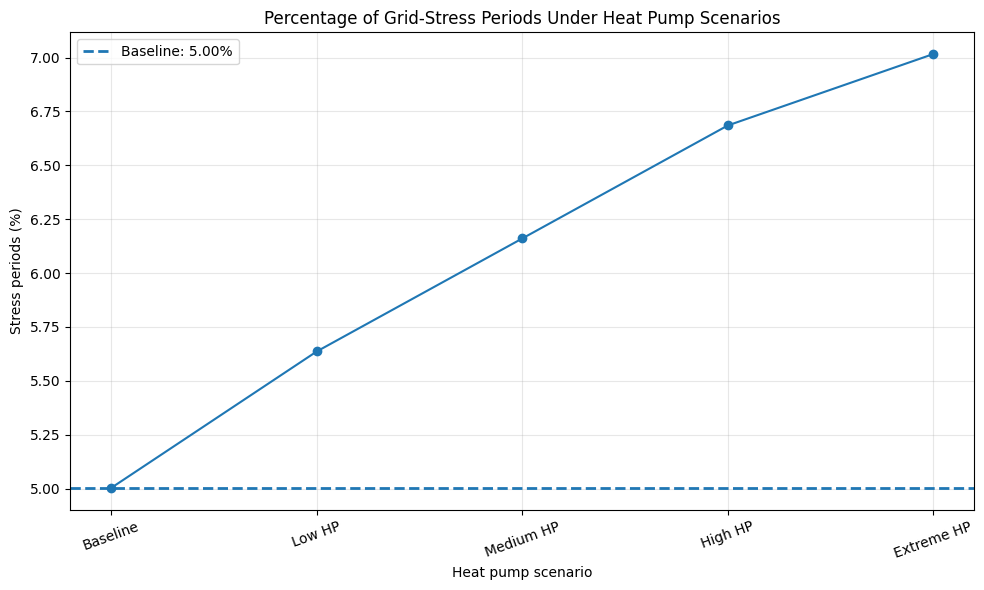

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(
    hp_results["Scenario"],
    hp_results["Stress_Percentage"],
    marker="o"
)

plt.axhline(
    baseline_stress_percentage,
    linestyle="--",
    linewidth=2,
    label=(
        f"Baseline: "
        f"{baseline_stress_percentage:.2f}%"
    )
)

plt.title(
    "Percentage of Grid-Stress Periods "
    "Under Heat Pump Scenarios"
)
plt.xlabel("Heat pump scenario")
plt.ylabel("Stress periods (%)")
plt.xticks(rotation=20)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "heat_pump_stress_percentage_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

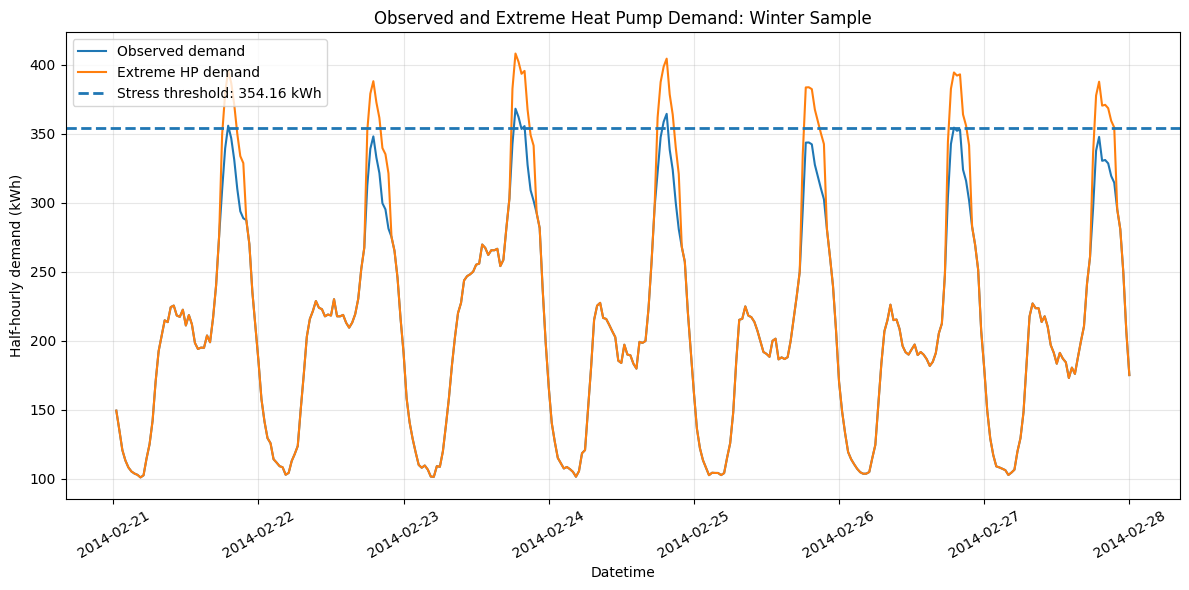

In [38]:
winter_extreme = (
    hp_scenario_datasets["Extreme HP"]
    .loc[
        hp_scenario_datasets[
            "Extreme HP"
        ]["is_winter"]
    ]
    .copy()
)

plot_sample = winter_extreme.tail(48 * 7)

plt.figure(figsize=(12, 6))

plt.plot(
    plot_sample["datetime"],
    plot_sample["total_demand_kwh"],
    label="Observed demand"
)

plt.plot(
    plot_sample["datetime"],
    plot_sample["simulated_demand_kwh"],
    label="Extreme HP demand"
)

plt.axhline(
    stress_threshold,
    linestyle="--",
    linewidth=2,
    label=(
        f"Stress threshold: "
        f"{stress_threshold:.2f} kWh"
    )
)

plt.title(
    "Observed and Extreme Heat Pump Demand: "
    "Winter Sample"
)
plt.xlabel("Datetime")
plt.ylabel("Half-hourly demand (kWh)")
plt.xticks(rotation=30)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "extreme_heat_pump_demand_timeline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
results_summary = pd.DataFrame({
    "Scenario": [
        "Baseline",
        "EV_80",
        "HP_40"
    ],
    "Stress_Percentage": [
        5.00,
        12.54,
        8.03
    ]
})

In [40]:
phase10_summary = hp_results[
    [
        "Scenario",
        "Additional_HP_Load_kWh",
        "Stress_Events",
        "Stress_Percentage",
        "Increase_From_Baseline",
        "Percentage_Point_Increase"
    ]
].copy()

display(phase10_summary)

phase10_summary.to_csv(
    TABLE_DIR / "phase10_heat_pump_summary.csv",
    index=False
)

,Scenario,Additional_HP_Load_kWh,Stress_Events,Stress_Percentage,Increase_From_Baseline,Percentage_Point_Increase
0,Baseline,0,1011,5.002722,0,0.000000
1,Low HP,10,1139,5.636103,128,0.633381
2,Medium HP,20,1245,6.160622,234,1.157900
3,High HP,30,1351,6.685140,340,1.682419
4,Extreme HP,40,1418,7.016676,407,2.013954


In [41]:
print(
    "PHASE 10: HEAT PUMP DATA ANALYSIS "
    "AND SIMULATION COMPLETED"
)

print(
    "--------------------------------"
    "---------------------"
)

print(
    f"Heat pump workbook: "
    f"{heat_pump_file.name}"
)

print(
    f"Demand file: {demand_file}"
)

print(
    f"Stress threshold: "
    f"{stress_threshold:.4f} kWh"
)

print(
    f"Baseline stress events: "
    f"{baseline_stress_events}"
)

print(
    f"Baseline stress percentage: "
    f"{baseline_stress_percentage:.4f}%"
)

print()

display(hp_annual)
display(hp_results)

PHASE 10: HEAT PUMP DATA ANALYSIS AND SIMULATION COMPLETED
-----------------------------------------------------
Heat pump workbook: Heat_pump_deployment_quarterly_statistics_United_Kingdom_2025_Q4.xlsx
Demand file: ..\data\processed\model_ready_data.csv
Stress threshold: 354.1552 kWh
Baseline stress events: 1011
Baseline stress percentage: 5.0027%



,Year,Air_Source_Heat_Pumps,Ground_Source_Heat_Pumps,Total_Heat_Pumps
0,2018,6665.0,662.0,7327.0
1,2019,9473.0,779.0,10252.0
2,2020,10250.0,946.0,11196.0
3,2021,21785.0,1722.0,23507.0
4,2022,24585.0,1707.0,26292.0
5,2023,31895.0,498.0,32393.0
6,2024,48318.0,359.0,48677.0
7,2025,51609.0,277.0,51886.0


,Scenario,Additional_HP_Load_kWh,Stress_Events,Stress_Percentage,Increase_From_Baseline,Relative_Increase_Percent,Percentage_Point_Increase
0,Baseline,0,1011,5.002722,0,0.000000,0.000000
1,Low HP,10,1139,5.636103,128,12.660732,0.633381
2,Medium HP,20,1245,6.160622,234,23.145401,1.157900
3,High HP,30,1351,6.685140,340,33.630069,1.682419
4,Extreme HP,40,1418,7.016676,407,40.257171,2.013954


In [42]:
for index, column in enumerate(hp_table.columns):
    print(index, repr(column))

0 'Source: Microgeneration Certification Scheme (MCS) Installation Database'
1 'Unnamed: 1'
2 'Unnamed: 2'
3 'Unnamed: 3'
